# Example: CCV denoising on a simulated ROI


```bash
conda run -n crikit3 python bcars_processing/step2_process.py --config examples/params_example.yaml
```

In [1]:
import os, sys
from pathlib import Path
import numpy as np, scipy.io as sio, matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bcars_processing").is_dir())
sys.path[:0] = [str(REPO / "bcars_processing/ccvsvd"), str(REPO / "bcars_processing/kk_pec")]
from SVD_utils import compute_crosscov_svd
from criteria import select_by_corr, RECON
from postprocess import PostprocessConfig, retrieve_phase
from crikit.cri.error_correction import PhaseErrCorrectALS

m  = sio.loadmat(REPO / "examples/sim_roi_AD_05.mat")
Z  = np.asarray(m["y_0_real"], np.float64)     # noisy, post-VST, normalized to [0,1]
GT = np.asarray(m["img_clean"], np.float64)    # exact ground truth, same domain
wn = np.asarray(m["wn"]).ravel()
print("ROI", Z.shape, "| wavenumbers %.0f-%.0f cm^-1" % (wn[0], wn[-1]))

DR = GT.max() - GT.min()
psnr = lambda x: 10 * np.log10(DR**2 / ((x - GT)**2).mean())

ROI (64, 64, 695) | wavenumbers 402-1799 cm^-1


## 1. Denoise — CCV picks its own rank


In [ ]:
cc = compute_crosscov_svd(Z)
keep, r = select_by_corr(cc, tau=0.5)
den = RECON["symmetric"](cc, Z, keep, smooth=0.0)


CCV kept 2 of 347 components (tau=0.5)
split-half correlation of the first six: [0.915 0.736 0.469 0.494 0.495 0.473]

PSNR vs ground truth
  noisy      20.03 dB
  CCV        40.66 dB   (+20.63 dB)


## 2. Before / after, in the dispersive (post-VST) domain

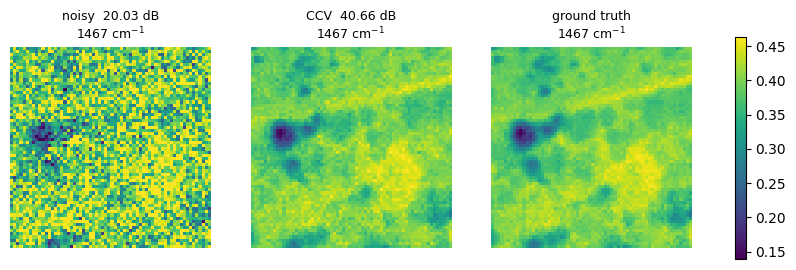

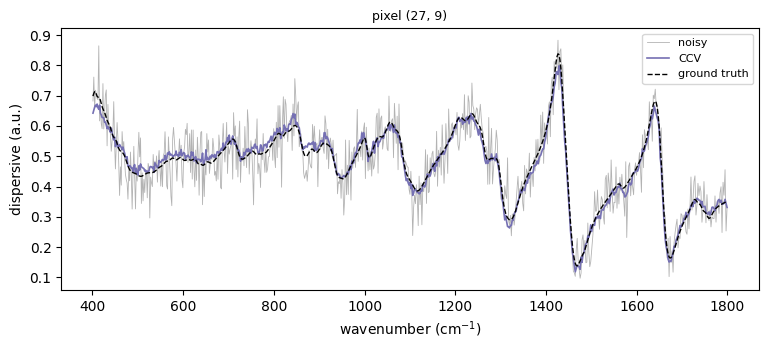

In [3]:
band = int(np.argmax(GT.std(axis=(0, 1))))            # most structured band
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, img, t in zip(ax, [Z[..., band], den[..., band], GT[..., band]],
                     ["noisy  %.2f dB" % psnr(Z), "CCV  %.2f dB" % psnr(den), "ground truth"]):
    im = a.imshow(img, cmap="viridis", vmin=GT[..., band].min(), vmax=GT[..., band].max())
    a.set_title("%s\n%.0f cm$^{-1}$" % (t, wn[band]), fontsize=9); a.axis("off")
fig.colorbar(im, ax=ax, shrink=0.8); plt.show()

iy, ix = np.unravel_index(int(np.argmax(GT.std(axis=2))), GT.shape[:2])   # most structured pixel
fig, a = plt.subplots(figsize=(9, 3.4))
a.plot(wn, Z[iy, ix], lw=0.6, color="0.7", label="noisy")
a.plot(wn, den[iy, ix], lw=1.2, color="#7570b3", label="CCV")
a.plot(wn, GT[iy, ix], lw=1.0, color="k", ls="--", label="ground truth")
a.set_xlabel("wavenumber (cm$^{-1}$)"); a.set_ylabel("dispersive (a.u.)")
a.set_title("pixel (%d, %d)" % (iy, ix), fontsize=9); a.legend(fontsize=8); plt.show()

## 3. Through phase retrieval to Raman

The same chain `step2_process.py` runs: Kramers–Kronig phase retrieval plus phase-error
correction, then the imaginary part. These are the simulated-data settings (the experimental
cubes use the Hilbert transform — see `params.yaml`).

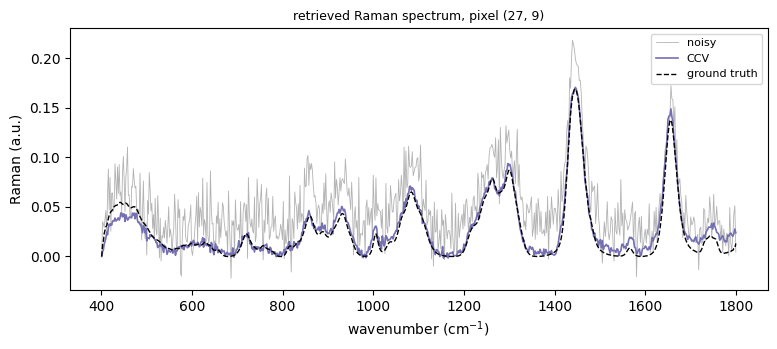

In [4]:
cfg = PostprocessConfig(
    phase_method="kk", cars_amp_offset=1.0, nrb_amp_offset=1.0, conjugate=False,
    phase_offset=0.0, norm_to_nrb=True, pad_factor=1, n_edge=30, bad_value=1e-8,
    phase_err_correct=True,
    pec_kwargs=dict(smoothness_param=1, asym_param=1e-5, redux=5, order=2,
                    max_iter=100, min_diff=1e-6, verbose=False))

def to_raman(cube):
    sp = retrieve_phase(cube, cfg)
    sp = PhaseErrCorrectALS(**cfg.pec_kwargs).calculate(sp)
    return np.imag(sp)

raman = {k: to_raman(v) for k, v in [("noisy", Z), ("CCV", den), ("ground truth", GT)]}

fig, a = plt.subplots(figsize=(9, 3.4))
for k, c, lw in [("noisy", "0.7", 0.6), ("CCV", "#7570b3", 1.2), ("ground truth", "k", 1.0)]:
    a.plot(wn, raman[k][iy, ix], lw=lw, color=c, ls="--" if k == "ground truth" else "-", label=k)
a.set_xlabel("wavenumber (cm$^{-1}$)"); a.set_ylabel("Raman (a.u.)")
a.set_title("retrieved Raman spectrum, pixel (%d, %d)" % (iy, ix), fontsize=9)
a.legend(fontsize=8); plt.show()

## 4. Against the shell run

`bash bcars_processing/run_pipeline.sh examples/params_example.yaml` writes
`examples/output/sim_roi_AD_05_raman.tif` through exactly this chain. If you ran it, the cell
below loads that file and checks it matches what this notebook just computed.


In [ ]:
import tifffile as tiff

out = REPO / "examples/output/sim_roi_AD_05_raman.tif"
if out.exists():
    shell = np.transpose(tiff.imread(str(out)).astype(np.float64), (1, 2, 0))   # (wn,y,x) -> (y,x,wn)
    here  = raman["CCV"]
    print("shell output :", shell.shape)
    print("max |difference| : %.3e" % np.abs(shell - here).max())
    print("Pearson r        : %.6f" % np.corrcoef(shell.ravel(), here.ravel())[0, 1])
else:
    print("run the shell command first:")
    print("  bash bcars_processing/run_pipeline.sh examples/params_example.yaml")